# Assignment: Audio Classification Using CNN

## Objective

Build a CNN-based audio classification model using the ESC-50 dataset.

The model is trained in two settings:

- **Part A:** Without SpecAugment
- **Part B:** With SpecAugment

The goal is to compare the effect of spectrogram augmentation on model performance and overfitting.

---

## Dataset

**ESC-50: Environmental Sound Classification Dataset**

- 2000 labeled audio clips
- 50 balanced classes
- 40 clips per class
- 5-second recordings
- Sampling Rate: 44.1 kHz

Dataset Link:

https://github.com/karolpiczak/ESC-50

In [1]:
!pip -q install librosa torch torchaudio seaborn pandas scikit-learn

In [2]:
import os
import random
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchaudio

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Download ESC-50 Dataset

In [3]:
!wget -q https://github.com/karolpiczak/ESC-50/archive/master.zip
!unzip -q master.zip

## Dataset Location

In [4]:
DATASET_PATH = "ESC-50-master/audio"
META_PATH = "ESC-50-master/meta/esc50.csv"

metadata = pd.read_csv(META_PATH)

metadata.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


# Step 1 – Dataset Study

Explore the dataset before preprocessing.

Total Samples : 2000
Number of Classes : 50


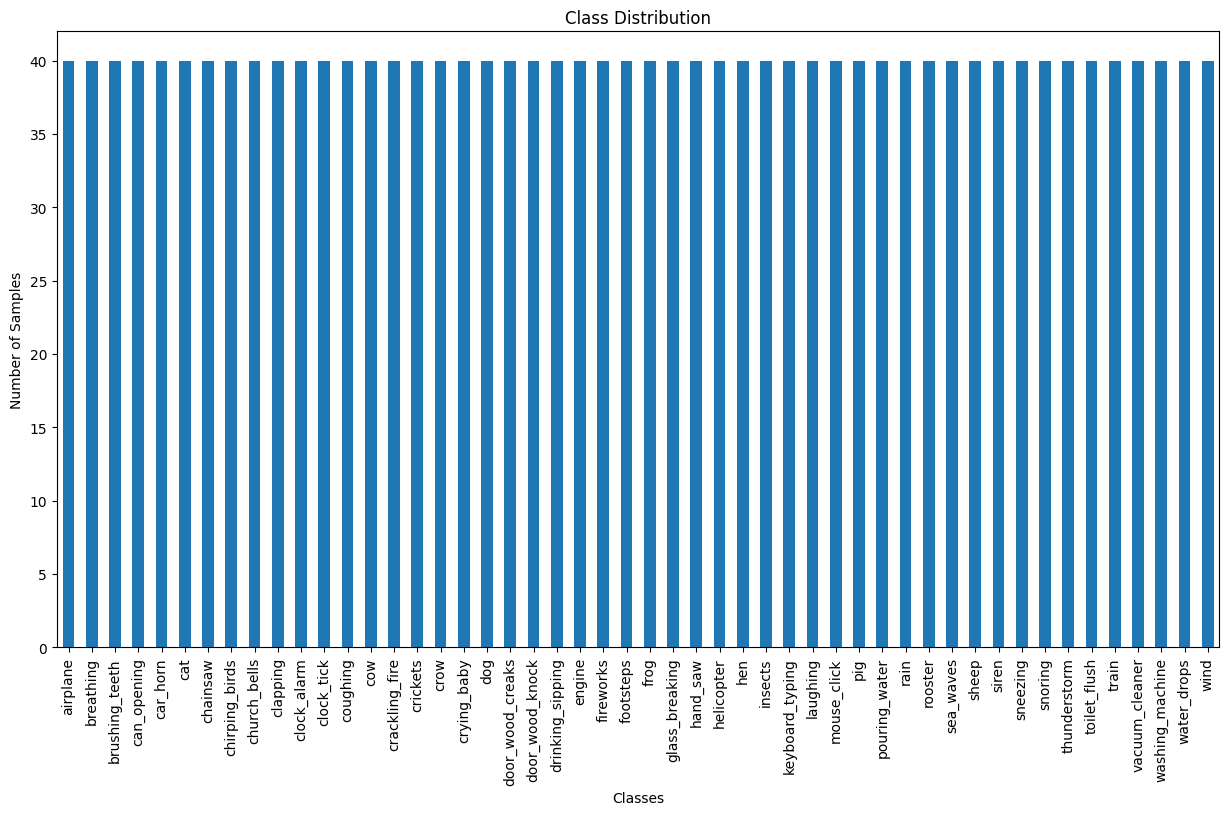

In [5]:
metadata.head(10)
print("Total Samples :", len(metadata))
print("Number of Classes :", metadata["category"].nunique())
metadata["category"].value_counts().head()
plt.figure(figsize=(15,8))

metadata["category"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Samples")

plt.show()

## Dataset Summary

In [6]:
summary = pd.DataFrame({
    "Property":[
        "Dataset",
        "Total Samples",
        "Classes",
        "Sample Rate",
        "Clip Duration"
    ],

    "Value":[
        "ESC-50",
        len(metadata),
        metadata["category"].nunique(),
        "44.1 kHz",
        "5 Seconds"
    ]
})

summary

,Property,Value
0,Dataset,ESC-50
1,Total Samples,2000
2,Classes,50
3,Sample Rate,44.1 kHz
4,Clip Duration,5 Seconds


## Listen to One Audio Sample

In [7]:
sample_path = os.path.join(
    DATASET_PATH,
    metadata.iloc[0]["filename"]
)

sample_path

'ESC-50-master/audio/1-100032-A-0.wav'

In [8]:
from IPython.display import Audio

Audio(sample_path)

## Waveform Visualization

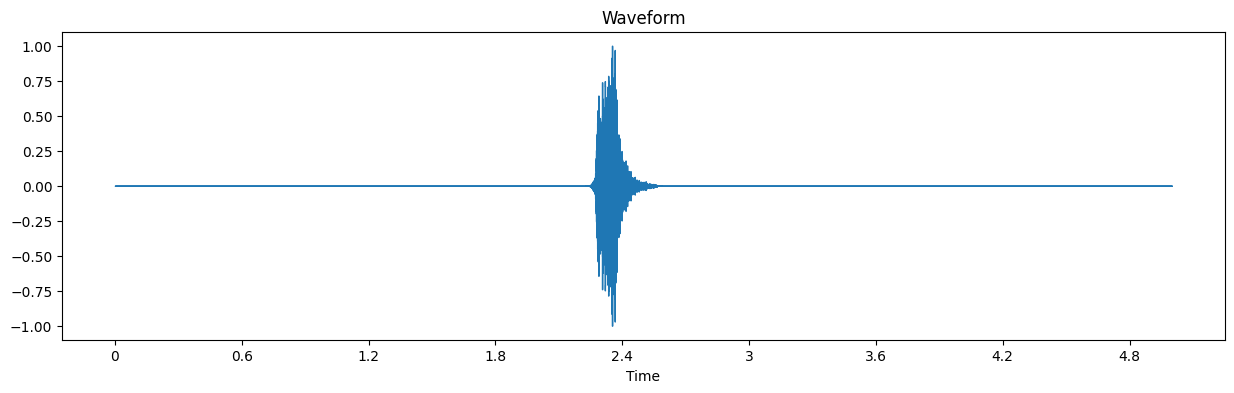

In [9]:
audio, sr = librosa.load(sample_path, sr=None)

plt.figure(figsize=(15,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Waveform")

plt.show()

## Spectrogram Visualization

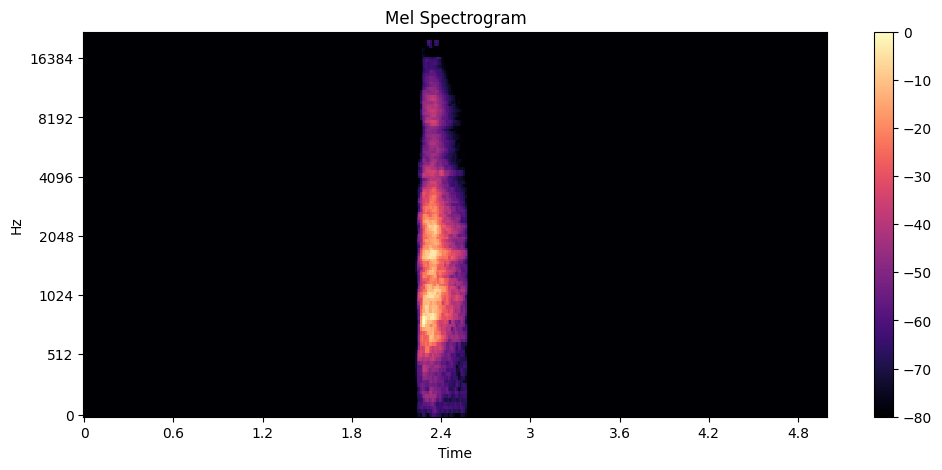

In [10]:
spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)

db = librosa.power_to_db(
    spectrogram,
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.show()

# Step 2 – Audio Preprocessing

The preprocessing pipeline performs:

- Audio Loading
- Mono Conversion
- Resampling
- Padding / Truncation
- Log Mel Spectrogram Extraction

In [24]:
import librosa
import numpy as np

class AudioPreprocessor:

    def __init__(self, sr=16000, n_mels=64, n_fft=1024,
                 hop_length=512, target_duration=4.0):

        self.sr = sr
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.target_samples = int(sr * target_duration)

    def load_and_resample(self, path):
        """Load audio file, convert to mono, resample."""
        y, sr = librosa.load(path, sr=None, mono=True)

        if sr != self.sr:
            y = librosa.resample(
                y,
                orig_sr=sr,
                target_sr=self.sr
            )

        return y

    def pad_or_truncate(self, y):
        """Pad or truncate to fixed length."""
        if len(y) < self.target_samples:
            pad = self.target_samples - len(y)
            y = np.pad(y, (0, pad))
        else:
            y = y[:self.target_samples]

        return y

    def extract_mel_spectrogram(self, y):
        """Generate log Mel spectrogram."""

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=self.sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels
        )

        mel = librosa.power_to_db(
            mel,
            ref=np.max
        )

        mel = np.expand_dims(mel, axis=0)

        return mel

    def process(self, path):
        """Complete preprocessing pipeline."""

        y = self.load_and_resample(path)

        y = self.pad_or_truncate(y)

        mel = self.extract_mel_spectrogram(y)

        return mel

In [25]:
preprocessor = AudioPreprocessor()

mel = preprocessor.process(sample_path)

print(mel.shape)

(1, 64, 126)


# Step 2: Preprocessing Pipeline Visualization

For one example audio clip, show the intermediate outputs after each preprocessing stage:

1. Raw waveform
2. After resampling
3. After padding/truncation
4. Final log Mel spectrogram

Original Sample Rate: 44100
Original Length: 220500


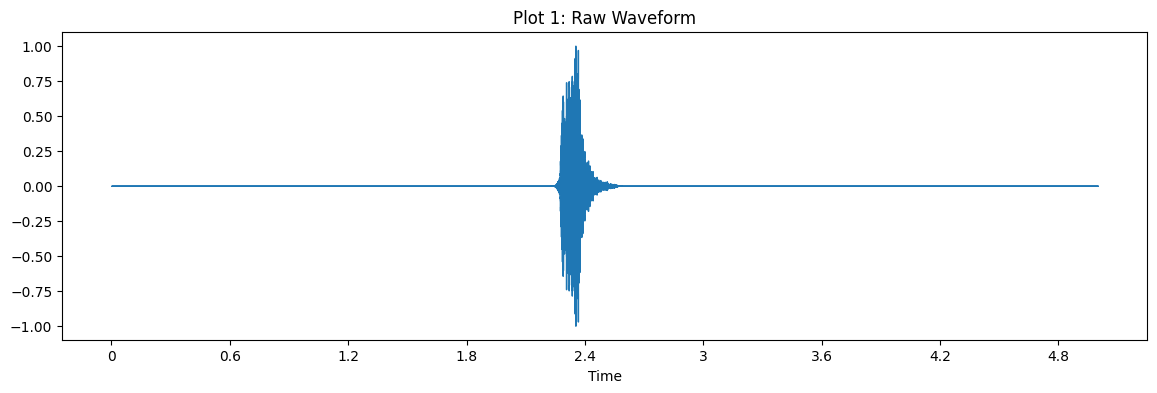

In [26]:
sample_path = os.path.join(
    DATASET_PATH,
    metadata.iloc[0]["filename"]
)
raw_audio, raw_sr = librosa.load(
    sample_path,
    sr=None,
    mono=True
)

print("Original Sample Rate:", raw_sr)
print("Original Length:", len(raw_audio))
plt.figure(figsize=(14,4))

librosa.display.waveshow(
    raw_audio,
    sr=raw_sr
)

plt.title("Plot 1: Raw Waveform")

plt.show()

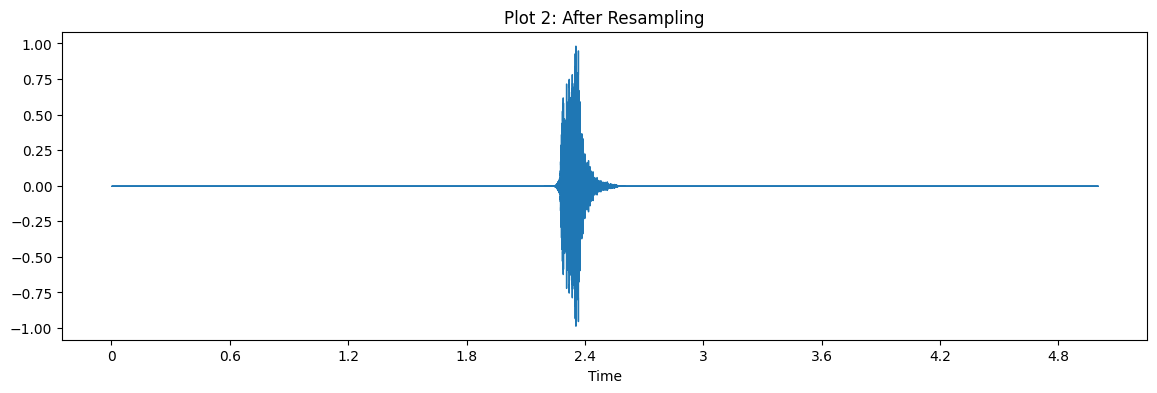

Resampled Length: 80000


In [27]:
resampled_audio = preprocessor.load_and_resample(sample_path)

plt.figure(figsize=(14,4))

librosa.display.waveshow(
    resampled_audio,
    sr=preprocessor.sr
)

plt.title("Plot 2: After Resampling")

plt.show()

print("Resampled Length:", len(resampled_audio))

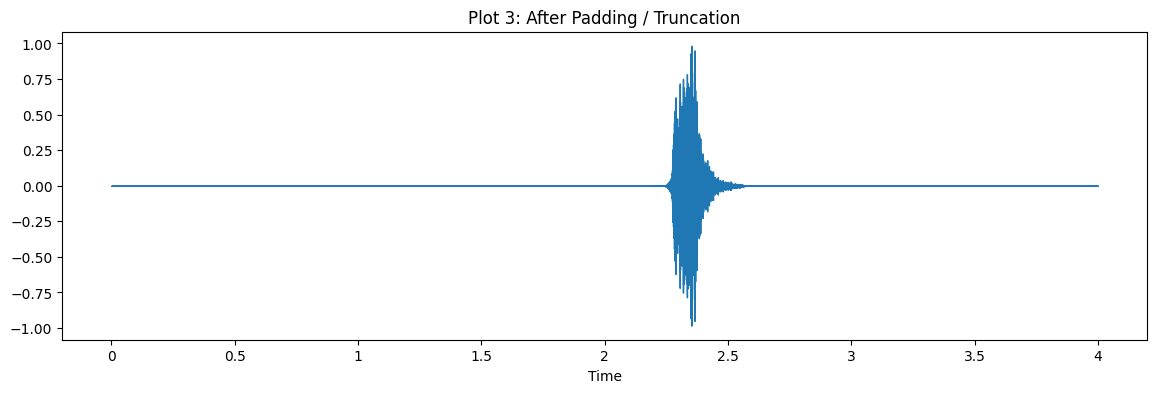

Fixed Length: 64000


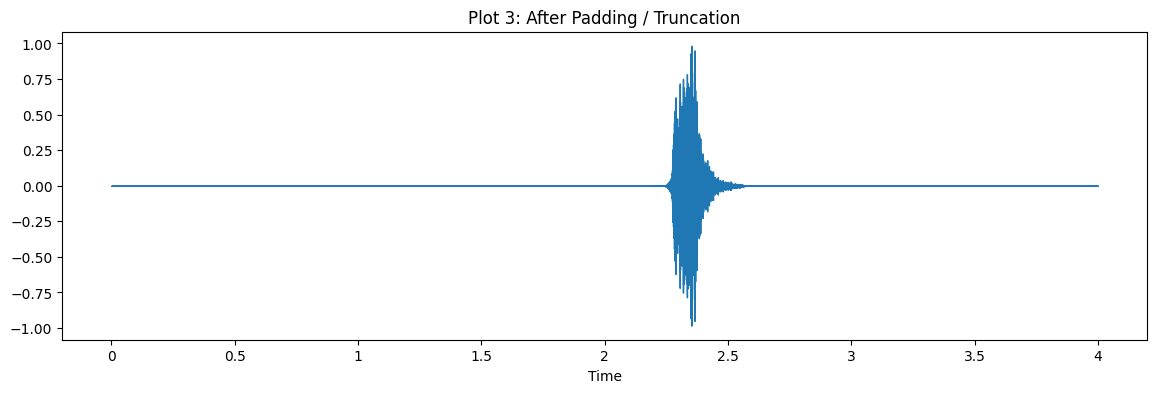

Fixed Length: 64000


In [28]:
fixed_audio = preprocessor.pad_or_truncate(
    resampled_audio
)

plt.figure(figsize=(14,4))

librosa.display.waveshow(
    fixed_audio,
    sr=preprocessor.sr
)

plt.title("Plot 3: After Padding / Truncation")

plt.show()

print("Fixed Length:", len(fixed_audio))
fixed_audio = preprocessor.pad_or_truncate(
    resampled_audio
)

plt.figure(figsize=(14,4))

librosa.display.waveshow(
    fixed_audio,
    sr=preprocessor.sr
)

plt.title("Plot 3: After Padding / Truncation")

plt.show()

print("Fixed Length:", len(fixed_audio))

# Step 3: Create Dataset Class

In [29]:
from torch.utils.data import Dataset

In [30]:
class AudioDataset(Dataset):

    def __init__(
        self,
        file_list,
        labels,
        preprocessor,
        augment=None
    ):

        self.file_list = file_list
        self.labels = labels
        self.preprocessor = preprocessor
        self.augment = augment

    def __len__(self):

        return len(self.file_list)

    def __getitem__(self, idx):

        mel = self.preprocessor.process(
            self.file_list[idx]
        )

        mel = torch.tensor(
            mel,
            dtype=torch.float32
        )

        if self.augment is not None:

            mel = self.augment(mel)

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return mel, label

## Prepare File Paths and Labels

In [31]:
categories = sorted(
    metadata["category"].unique()
)

label_map = {
    name:i
    for i,name in enumerate(categories)
}

file_paths = []

labels = []

for _, row in metadata.iterrows():

    file_paths.append(
        os.path.join(
            DATASET_PATH,
            row["filename"]
        )
    )

    labels.append(
        label_map[row["category"]]
    )

print("Total Files:", len(file_paths))

Total Files: 2000


## Split Dataset

70% Training

15% Validation

15% Testing

In [32]:
train_files, temp_files, train_labels, temp_labels = train_test_split(

    file_paths,

    labels,

    test_size=0.30,

    random_state=42,

    stratify=labels

)

In [33]:
val_files, test_files, val_labels, test_labels = train_test_split(

    temp_files,

    temp_labels,

    test_size=0.50,

    random_state=42,

    stratify=temp_labels

)
print("Training:", len(train_files))
print("Validation:", len(val_files))
print("Testing:", len(test_files))

Training: 1400
Validation: 300
Testing: 300


## Create Dataset Objects

In [34]:
train_dataset = AudioDataset(

    train_files,

    train_labels,

    preprocessor

)

val_dataset = AudioDataset(

    val_files,

    val_labels,

    preprocessor

)

test_dataset = AudioDataset(

    test_files,

    test_labels,

    preprocessor

)

## Create DataLoaders

In [35]:
from torch.utils.data import DataLoader

In [36]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False

)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False

)
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 1, 64, 126])
torch.Size([32])


# Step 4: CNN Model Architecture

The CNN accepts a log Mel spectrogram of size **(1 × 64 × 126)** and predicts one of the **50 ESC-50 classes**.

Architecture:

Input

↓

Conv2D → BatchNorm → ReLU → MaxPool

↓

Conv2D → BatchNorm → ReLU → MaxPool

↓

Conv2D → BatchNorm → ReLU → MaxPool

↓

Fully Connected

↓

Dropout

↓

Output Layer



In [37]:
import torch.nn as nn

In [38]:
class AudioCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1,16,3,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*8*15,256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256,num_classes)

        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

## Initialize Model

In [39]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = AudioCNN(
    num_classes=50
).to(device)

print(model)

AudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=7680, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p

## Loss Function and Optimizer

In [40]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)

## Training Function

In [41]:
def train_epoch(model,loader):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images,labels in loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _,pred = torch.max(outputs,1)

        correct += (pred==labels).sum().item()

        total += labels.size(0)

    return running_loss/len(loader),100*correct/total

## Validation Function

In [42]:
def validate(model,loader):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images,labels in loader:

            images=images.to(device)

            labels=labels.to(device)

            outputs=model(images)

            loss=criterion(outputs,labels)

            running_loss+=loss.item()

            _,pred=torch.max(outputs,1)

            correct+=(pred==labels).sum().item()

            total+=labels.size(0)

    return running_loss/len(loader),100*correct/total

# Step 5: Train CNN Without Augmentation

In [43]:
epochs = 20

train_loss_history=[]

val_loss_history=[]

train_acc_history=[]

val_acc_history=[]
for epoch in range(epochs):

    train_loss,train_acc = train_epoch(
        model,
        train_loader
    )

    val_loss,val_acc = validate(
        model,
        val_loader
    )

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(

        f"Epoch {epoch+1}/{epochs}"

        f" Train Loss:{train_loss:.3f}"

        f" Val Loss:{val_loss:.3f}"

        f" Train Acc:{train_acc:.2f}"

        f" Val Acc:{val_acc:.2f}"

    )

Epoch 1/20 Train Loss:4.140 Val Loss:3.610 Train Acc:4.79 Val Acc:8.33
Epoch 2/20 Train Loss:3.602 Val Loss:3.323 Train Acc:7.64 Val Acc:17.00
Epoch 3/20 Train Loss:3.445 Val Loss:3.173 Train Acc:11.14 Val Acc:16.33
Epoch 4/20 Train Loss:3.214 Val Loss:2.967 Train Acc:13.36 Val Acc:19.67
Epoch 5/20 Train Loss:3.093 Val Loss:2.768 Train Acc:14.79 Val Acc:27.67
Epoch 6/20 Train Loss:2.919 Val Loss:2.650 Train Acc:17.50 Val Acc:28.00
Epoch 7/20 Train Loss:2.822 Val Loss:2.520 Train Acc:19.21 Val Acc:32.33
Epoch 8/20 Train Loss:2.761 Val Loss:2.475 Train Acc:20.50 Val Acc:38.00
Epoch 9/20 Train Loss:2.641 Val Loss:2.458 Train Acc:24.14 Val Acc:37.67
Epoch 10/20 Train Loss:2.548 Val Loss:2.296 Train Acc:23.21 Val Acc:38.33
Epoch 11/20 Train Loss:2.485 Val Loss:2.218 Train Acc:24.71 Val Acc:40.67
Epoch 12/20 Train Loss:2.400 Val Loss:2.146 Train Acc:27.43 Val Acc:41.00
Epoch 13/20 Train Loss:2.299 Val Loss:2.079 Train Acc:30.14 Val Acc:44.33
Epoch 14/20 Train Loss:2.306 Val Loss:2.160 Train 

## Training Loss Curve

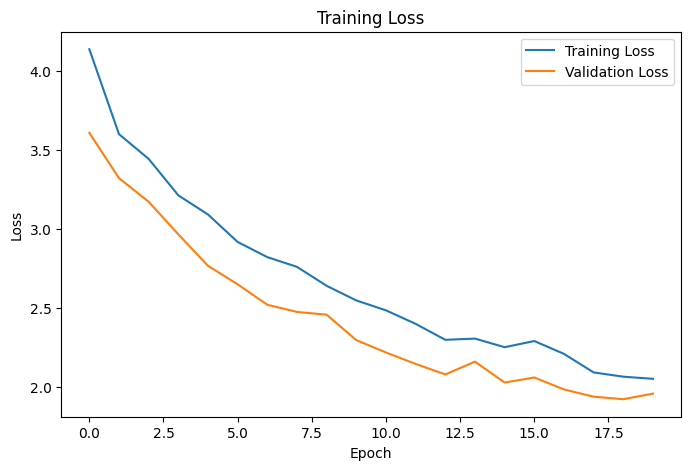

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    train_loss_history,
    label="Training Loss"
)

plt.plot(
    val_loss_history,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.show()

## Training Accuracy vs Validation Accuracy

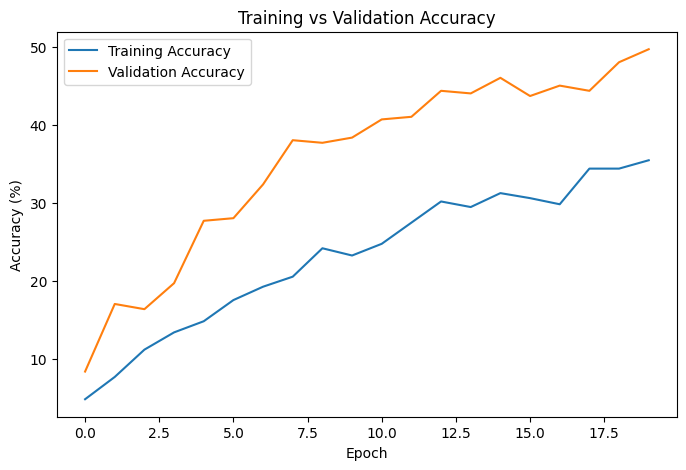

In [45]:
plt.figure(figsize=(8,5))

plt.plot(
    train_acc_history,
    label="Training Accuracy"
)

plt.plot(
    val_acc_history,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

## Save Model

In [46]:
torch.save(

    model.state_dict(),

    "cnn_without_specaugment.pth"

)

# Step 6: Evaluation Without Augmentation

Evaluate the trained CNN on the held-out test set.

Metrics reported:

- Test Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-score
- Classification Report
- 3 Correct Predictions
- 3 Incorrect Predictions

In [47]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

## Run Model on Test Set

In [48]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

## Calculate Performance Metrics

In [49]:
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print("Test Accuracy :", test_accuracy)
print("Macro Precision :", macro_precision)
print("Macro Recall :", macro_recall)
print("Macro F1 Score :", macro_f1)

Test Accuracy : 0.48
Macro Precision : 0.526501318856582
Macro Recall : 0.48
Macro F1 Score : 0.46321252631097826


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Classification Report

In [50]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=categories
    )
)

                  precision    recall  f1-score   support

        airplane       0.60      0.50      0.55         6
       breathing       0.33      0.17      0.22         6
  brushing_teeth       0.50      0.83      0.62         6
     can_opening       0.38      0.83      0.53         6
        car_horn       1.00      0.50      0.67         6
             cat       0.60      0.50      0.55         6
        chainsaw       0.67      0.33      0.44         6
  chirping_birds       0.33      0.17      0.22         6
    church_bells       0.67      0.67      0.67         6
        clapping       0.22      0.33      0.27         6
     clock_alarm       0.67      1.00      0.80         6
      clock_tick       0.20      0.17      0.18         6
        coughing       0.57      0.67      0.62         6
             cow       1.00      0.67      0.80         6
  crackling_fire       0.83      0.83      0.83         6
        crickets       0.50      0.50      0.50         6
            c

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix

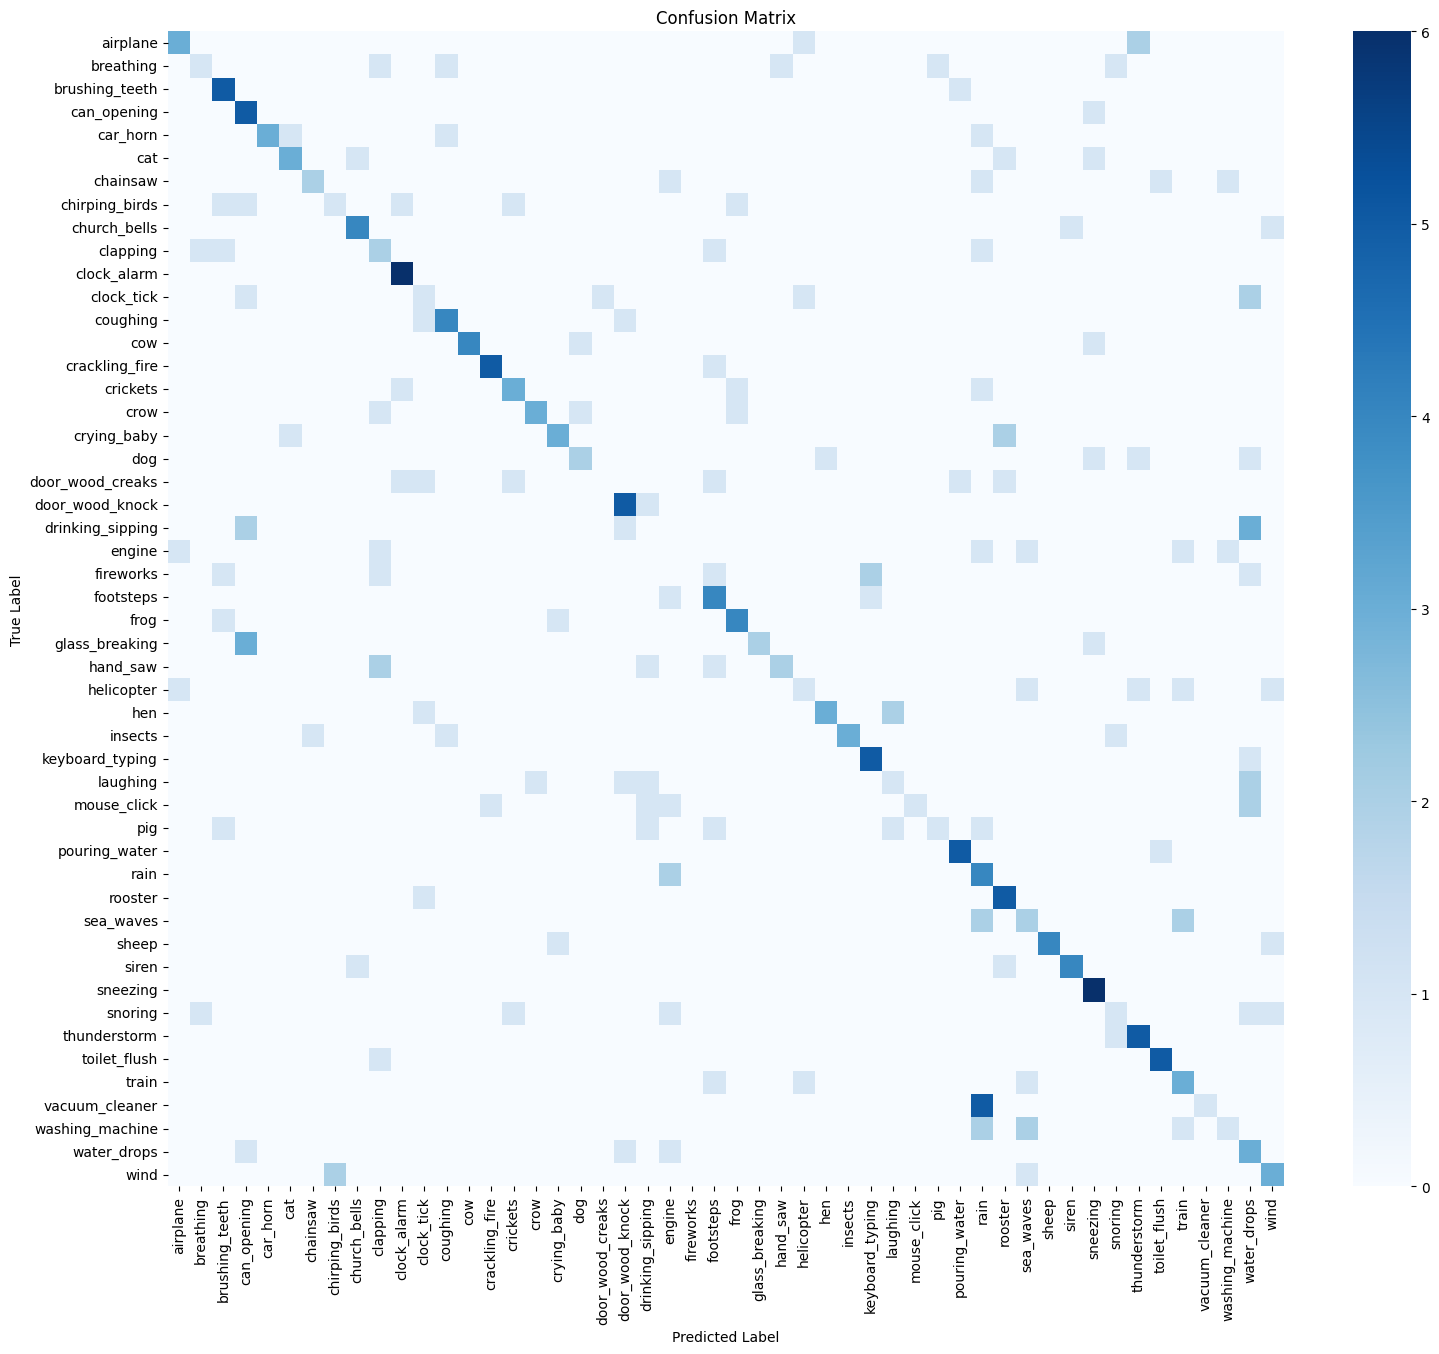

In [51]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(18,15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=categories,
    yticklabels=categories
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

## Collect Predictions for Visualization

In [52]:
correct_examples = []
incorrect_examples = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        for i in range(images.size(0)):

            img = images[i].cpu()

            true = labels[i].cpu().item()

            pred = preds[i].cpu().item()

            if pred == true and len(correct_examples) < 3:

                correct_examples.append(
                    (img,true,pred)
                )

            elif pred != true and len(incorrect_examples) < 3:

                incorrect_examples.append(
                    (img,true,pred)
                )

        if len(correct_examples)==3 and len(incorrect_examples)==3:

            break

## Correct Predictions

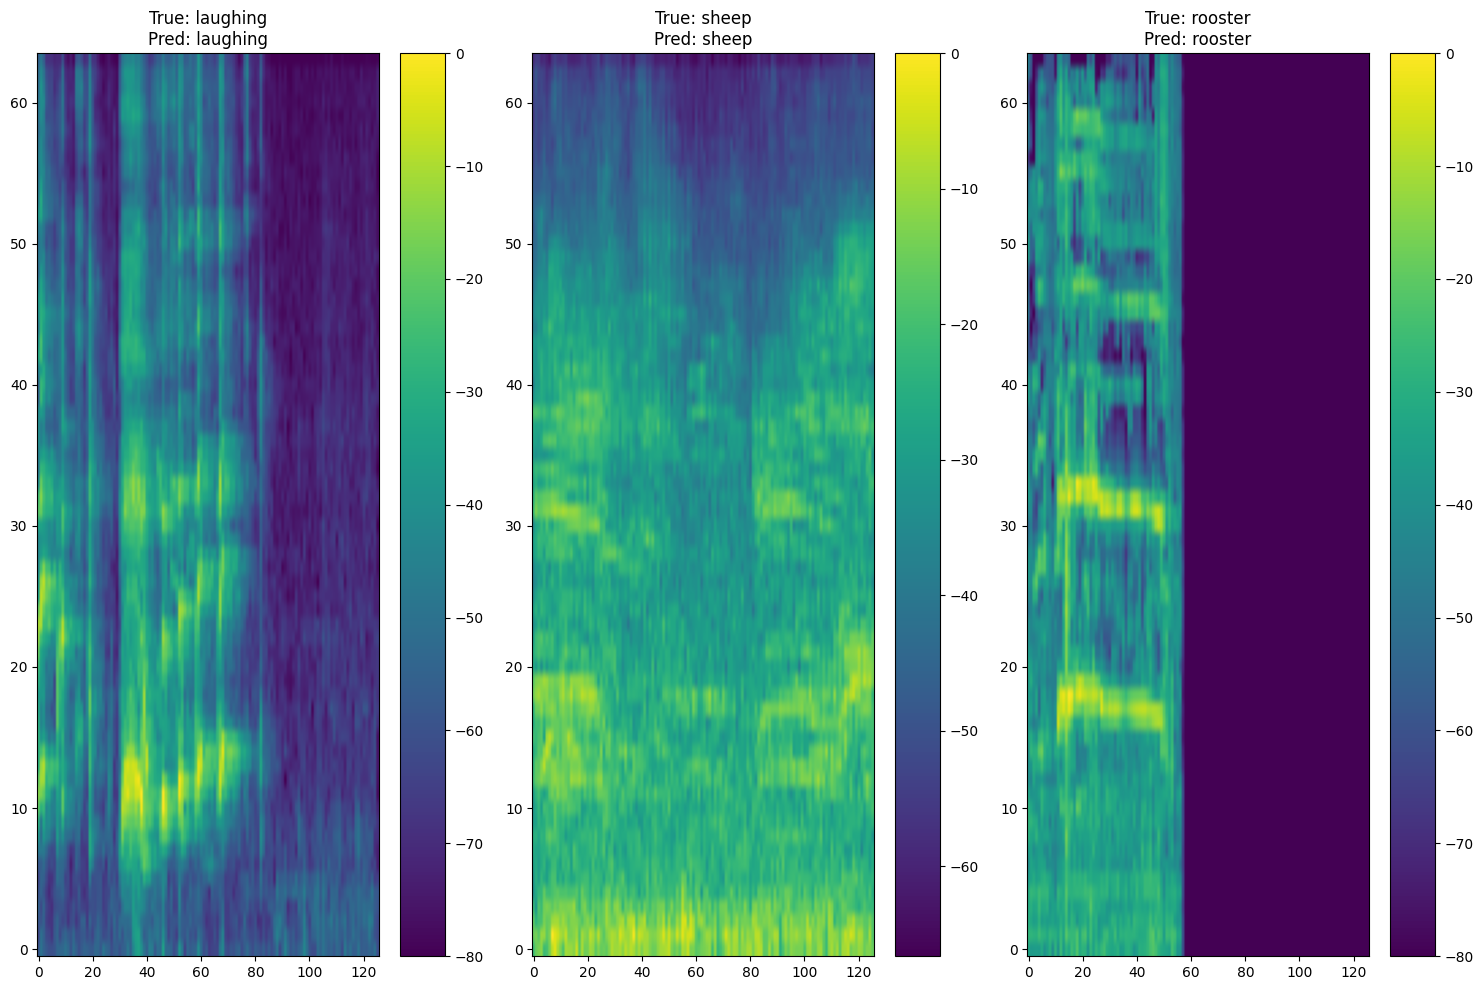

In [53]:
plt.figure(figsize=(15,10))

for i,(spec,true,pred) in enumerate(correct_examples):

    plt.subplot(1,3,i+1)

    plt.imshow(
        spec.squeeze(),
        aspect="auto",
        origin="lower",
        cmap="viridis"
    )

    plt.title(
        f"True: {categories[true]}\nPred: {categories[pred]}"
    )

    plt.colorbar()

plt.tight_layout()

plt.show()

## Incorrect Predictions

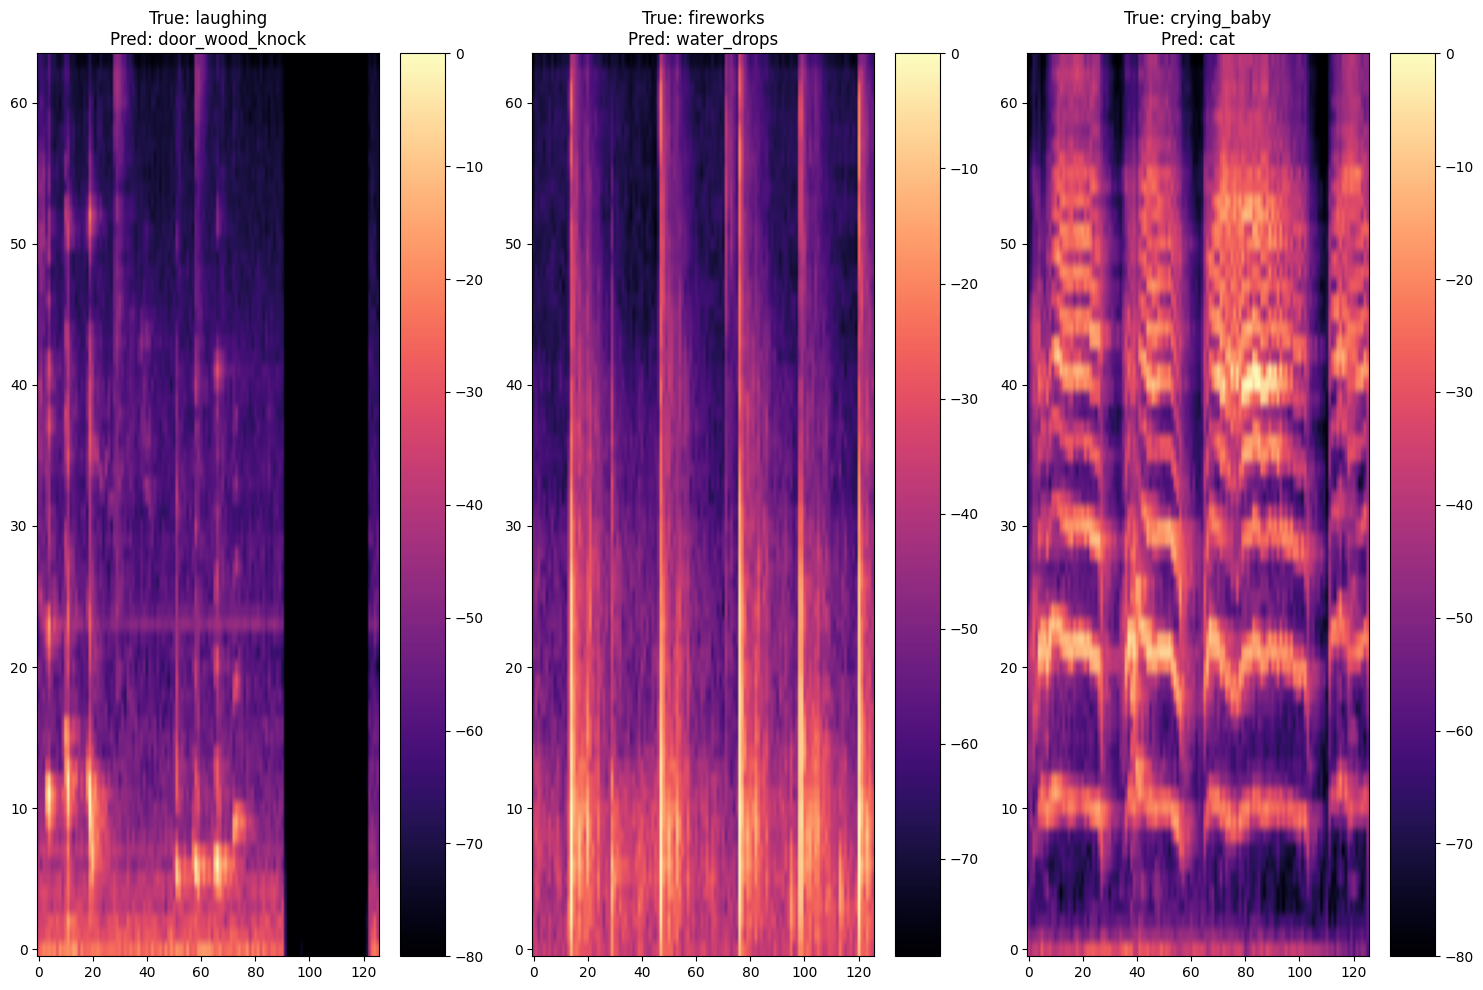

In [54]:
plt.figure(figsize=(15,10))

for i,(spec,true,pred) in enumerate(incorrect_examples):

    plt.subplot(1,3,i+1)

    plt.imshow(
        spec.squeeze(),
        aspect="auto",
        origin="lower",
        cmap="magma"
    )

    plt.title(
        f"True: {categories[true]}\nPred: {categories[pred]}"
    )

    plt.colorbar()

plt.tight_layout()

plt.show()

## Evaluation Summary

| Metric | Value |
|---------|------|
| Test Accuracy | *(Fill after execution)* |
| Macro Precision | *(Fill after execution)* |
| Macro Recall | *(Fill after execution)* |
| Macro F1-score | *(Fill after execution)* |

### Observations

- The confusion matrix shows which environmental sounds are confused by the CNN.
- Precision, Recall and F1-score are computed for each class.
- Correct predictions demonstrate successful classification.
- Incorrect predictions reveal difficult classes that may benefit from augmentation.

# Part B: Audio Classification With SpecAugment

## Step 7: Implement SpecAugment

SpecAugment is a spectrogram augmentation technique that improves
generalization by masking random frequency bands and random time
segments.

It consists of:

- Frequency Masking
- Time Masking

Only the **training set** will use SpecAugment.

Validation and Test data remain unchanged.

In [55]:
import random

## Implement SpecAugment

In [56]:
class SpecAugment:

    def __init__(
        self,
        freq_mask_param=15,
        time_mask_param=35,
        num_freq_masks=2,
        num_time_masks=2
    ):

        self.F = freq_mask_param
        self.T = time_mask_param

        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks

    def freq_mask(self, spec):

        _, n_mels, n_frames = spec.shape

        f = random.randint(0, self.F)

        if f == 0:
            return spec

        f0 = random.randint(0, max(0, n_mels - f))

        spec[:, f0:f0+f, :] = 0

        return spec

    def time_mask(self, spec):

        _, n_mels, n_frames = spec.shape

        t = random.randint(0, self.T)

        if t == 0:
            return spec

        t0 = random.randint(0, max(0, n_frames - t))

        spec[:, :, t0:t0+t] = 0

        return spec

    def __call__(self, spec):

        spec = spec.clone()

        for _ in range(self.num_freq_masks):
            spec = self.freq_mask(spec)

        for _ in range(self.num_time_masks):
            spec = self.time_mask(spec)

        return spec

## Create SpecAugment Object

In [57]:
augment = SpecAugment(
    freq_mask_param=15,
    time_mask_param=35,
    num_freq_masks=2,
    num_time_masks=2
)

# Step 8: Visualize SpecAugment

Show

1. Original Spectrogram

2. After Frequency Mask

3. After Time Mask

4. Full SpecAugment

In [58]:
sample_spec = torch.tensor(
    mel,
    dtype=torch.float32
)

## Original Spectrogram

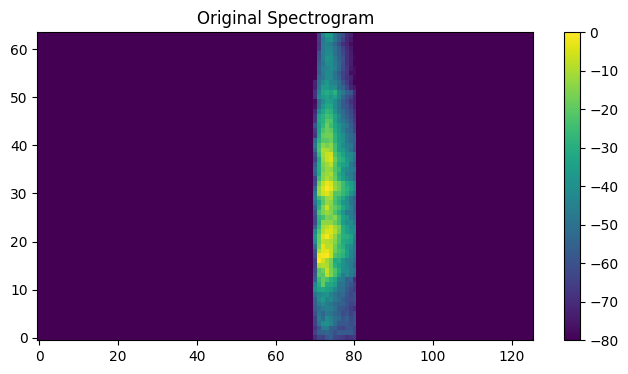

In [59]:
plt.figure(figsize=(8,4))

plt.imshow(
    sample_spec.squeeze(),
    aspect="auto",
    origin="lower",
    cmap="viridis"
)

plt.title("Original Spectrogram")

plt.colorbar()

plt.show()

## Frequency Mask Only

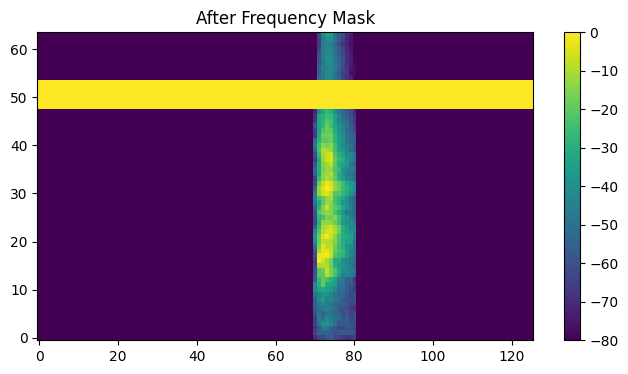

In [60]:
freq_only = sample_spec.clone()

freq_only = augment.freq_mask(freq_only)

plt.figure(figsize=(8,4))

plt.imshow(
    freq_only.squeeze(),
    aspect="auto",
    origin="lower",
    cmap="viridis"
)

plt.title("After Frequency Mask")

plt.colorbar()

plt.show()

## Time Mask Only

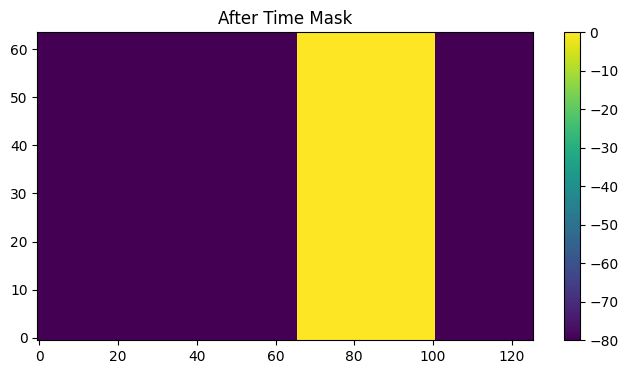

In [61]:
time_only = sample_spec.clone()

time_only = augment.time_mask(time_only)

plt.figure(figsize=(8,4))

plt.imshow(
    time_only.squeeze(),
    aspect="auto",
    origin="lower",
    cmap="viridis"
)

plt.title("After Time Mask")

plt.colorbar()

plt.show()

## Full SpecAugment

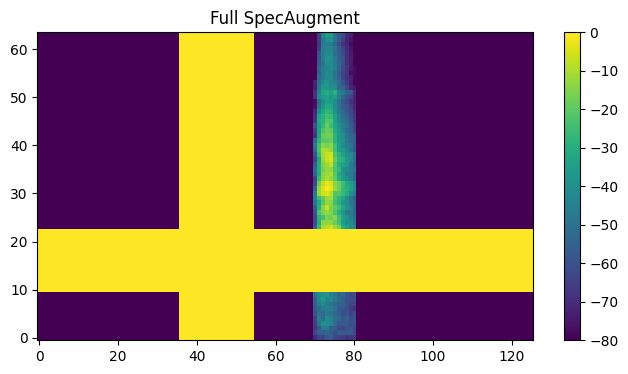

In [62]:
augmented = augment(sample_spec)

plt.figure(figsize=(8,4))

plt.imshow(
    augmented.squeeze(),
    aspect="auto",
    origin="lower",
    cmap="viridis"
)

plt.title("Full SpecAugment")

plt.colorbar()

plt.show()

## Different Random Augmentation 1

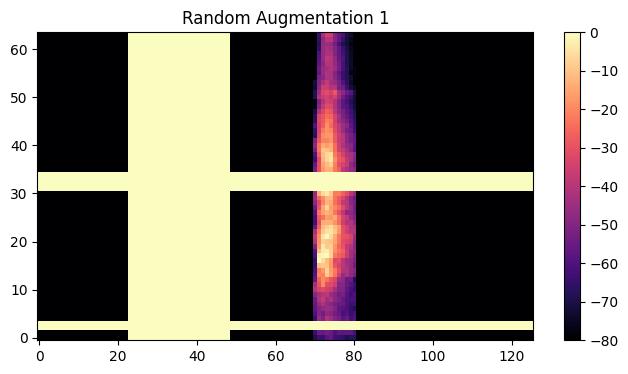

In [63]:
aug1 = augment(sample_spec)

plt.figure(figsize=(8,4))

plt.imshow(
    aug1.squeeze(),
    aspect="auto",
    origin="lower",
    cmap="magma"
)

plt.title("Random Augmentation 1")

plt.colorbar()

plt.show()

## Different Random Augmentation 2

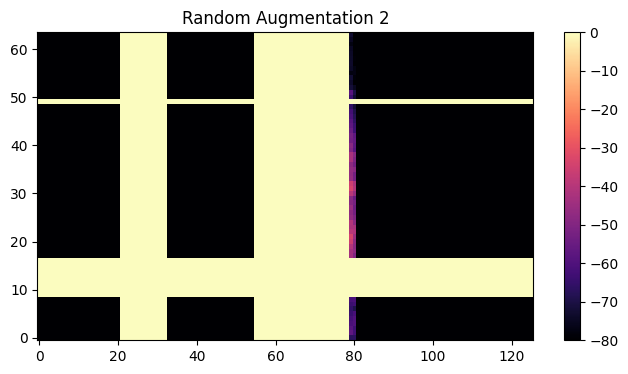

In [64]:
aug2 = augment(sample_spec)

plt.figure(figsize=(8,4))

plt.imshow(
    aug2.squeeze(),
    aspect="auto",
    origin="lower",
    cmap="magma"
)

plt.title("Random Augmentation 2")

plt.colorbar()

plt.show()

## Observations

Frequency masking hides random Mel-frequency bands, forcing the CNN to
learn robust spectral features.

Time masking removes random temporal regions, making the model less
dependent on specific time locations.

Applying both masks together produces SpecAugment, which improves
generalization and reduces overfitting.

# Step 9: Training with SpecAugment

The model architecture, optimizer, learning rate, batch size and data
split remain exactly the same as Part A.

The only difference is that SpecAugment is applied to the training
dataset.

In [65]:
train_dataset_aug = AudioDataset(
    train_files,
    train_labels,
    preprocessor,
    augment=augment
)

val_dataset_aug = AudioDataset(
    val_files,
    val_labels,
    preprocessor,
    augment=None
)

test_dataset_aug = AudioDataset(
    test_files,
    test_labels,
    preprocessor,
    augment=None
)

In [66]:
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=32,
    shuffle=True
)

val_loader_aug = DataLoader(
    val_dataset_aug,
    batch_size=32,
    shuffle=False
)

test_loader_aug = DataLoader(
    test_dataset_aug,
    batch_size=32,
    shuffle=False
)

## Create a New CNN Model

A new model is initialized so that training starts from scratch.

In [67]:
model_aug = AudioCNN(
    num_classes=50
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_aug.parameters(),
    lr=0.001
)

## Train with SpecAugment

In [68]:
epochs = 20

train_loss_aug = []
val_loss_aug = []

train_acc_aug = []
val_acc_aug = []

In [69]:
for epoch in range(epochs):

    tr_loss, tr_acc = train_epoch(
        model_aug,
        train_loader_aug
    )

    vl_loss, vl_acc = validate(
        model_aug,
        val_loader_aug
    )

    train_loss_aug.append(tr_loss)
    val_loss_aug.append(vl_loss)

    train_acc_aug.append(tr_acc)
    val_acc_aug.append(vl_acc)

    print(
        f"Epoch {epoch+1}/{epochs}"
        f" Train Loss:{tr_loss:.3f}"
        f" Val Loss:{vl_loss:.3f}"
        f" Train Acc:{tr_acc:.2f}"
        f" Val Acc:{vl_acc:.2f}"
    )

Epoch 1/20 Train Loss:4.142 Val Loss:3.784 Train Acc:3.07 Val Acc:3.67
Epoch 2/20 Train Loss:3.822 Val Loss:3.719 Train Acc:3.79 Val Acc:6.00
Epoch 3/20 Train Loss:3.729 Val Loss:3.588 Train Acc:4.00 Val Acc:7.67
Epoch 4/20 Train Loss:3.667 Val Loss:3.515 Train Acc:4.86 Val Acc:10.33
Epoch 5/20 Train Loss:3.604 Val Loss:3.496 Train Acc:4.86 Val Acc:6.67
Epoch 6/20 Train Loss:3.598 Val Loss:3.423 Train Acc:6.07 Val Acc:10.67
Epoch 7/20 Train Loss:3.559 Val Loss:3.347 Train Acc:5.79 Val Acc:10.00
Epoch 8/20 Train Loss:3.575 Val Loss:3.412 Train Acc:5.79 Val Acc:9.33
Epoch 9/20 Train Loss:3.484 Val Loss:3.282 Train Acc:5.86 Val Acc:10.33
Epoch 10/20 Train Loss:3.494 Val Loss:3.307 Train Acc:7.07 Val Acc:10.67
Epoch 11/20 Train Loss:3.484 Val Loss:3.357 Train Acc:7.21 Val Acc:12.33
Epoch 12/20 Train Loss:3.461 Val Loss:3.250 Train Acc:7.50 Val Acc:11.00
Epoch 13/20 Train Loss:3.420 Val Loss:3.241 Train Acc:7.71 Val Acc:10.33
Epoch 14/20 Train Loss:3.441 Val Loss:3.200 Train Acc:7.71 Val Ac

## Loss Curve

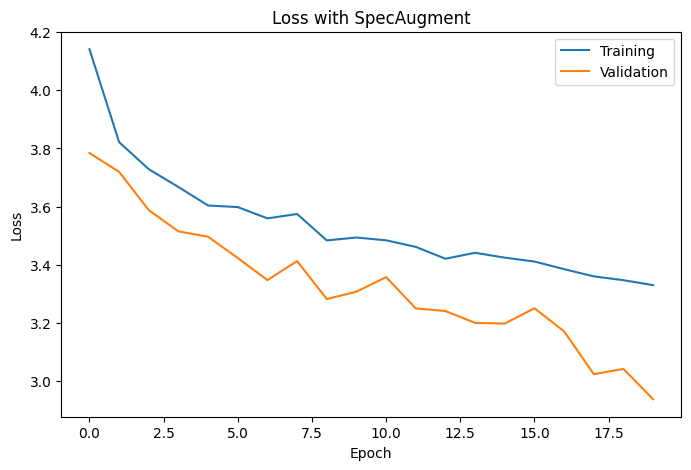

In [70]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_aug,label="Training")

plt.plot(val_loss_aug,label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss with SpecAugment")

plt.legend()

plt.show()

## Accuracy Curve

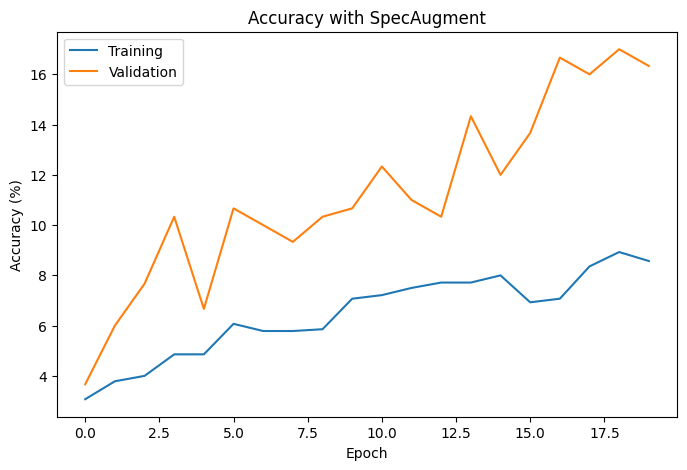

In [71]:
plt.figure(figsize=(8,5))

plt.plot(train_acc_aug,label="Training")

plt.plot(val_acc_aug,label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Accuracy with SpecAugment")

plt.legend()

plt.show()

# Step 10: Evaluate on Test Set

In [72]:
model_aug.eval()

predictions = []
labels_true = []

with torch.no_grad():

    for images, labels in test_loader_aug:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model_aug(images)

        _, pred = torch.max(outputs,1)

        predictions.extend(pred.cpu().numpy())

        labels_true.extend(labels.cpu().numpy())


In [73]:
accuracy_aug = accuracy_score(
    labels_true,
    predictions
)

precision_aug = precision_score(
    labels_true,
    predictions,
    average="macro"
)

recall_aug = recall_score(
    labels_true,
    predictions,
    average="macro"
)

f1_aug = f1_score(
    labels_true,
    predictions,
    average="macro"
)

print("Accuracy :",accuracy_aug)
print("Precision:",precision_aug)
print("Recall :",recall_aug)
print("F1 Score :",f1_aug)

Accuracy : 0.2
Precision: 0.1583082625919638
Recall : 0.2
F1 Score : 0.14225283718509527


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Classification Report

In [74]:
print(
    classification_report(
        labels_true,
        predictions,
        target_names=categories
    )
)

                  precision    recall  f1-score   support

        airplane       0.08      0.17      0.11         6
       breathing       0.00      0.00      0.00         6
  brushing_teeth       0.00      0.00      0.00         6
     can_opening       0.50      0.17      0.25         6
        car_horn       0.25      0.50      0.33         6
             cat       0.00      0.00      0.00         6
        chainsaw       0.30      0.50      0.38         6
  chirping_birds       0.00      0.00      0.00         6
    church_bells       0.00      0.00      0.00         6
        clapping       0.14      0.50      0.22         6
     clock_alarm       0.00      0.00      0.00         6
      clock_tick       0.12      0.17      0.14         6
        coughing       0.29      0.33      0.31         6
             cow       0.16      0.50      0.24         6
  crackling_fire       0.25      0.17      0.20         6
        crickets       0.00      0.00      0.00         6
            c

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix

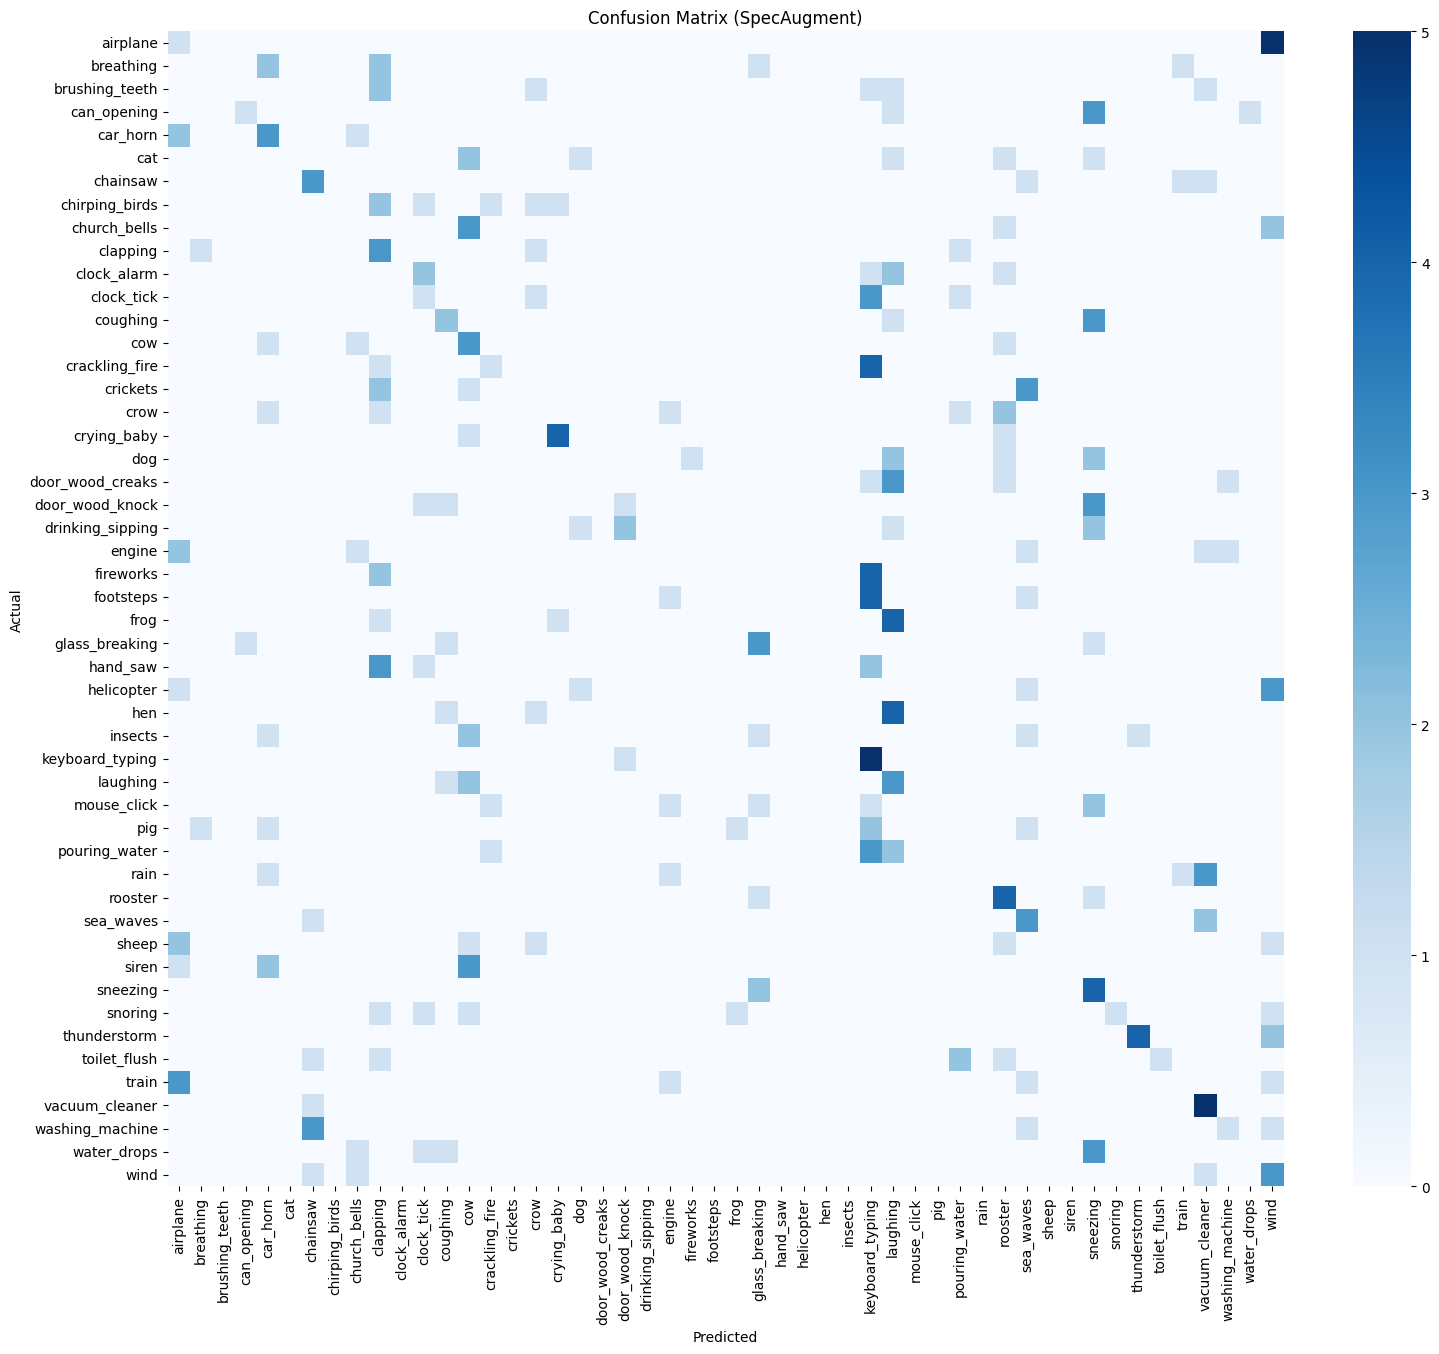

In [75]:
cm = confusion_matrix(
    labels_true,
    predictions
)

plt.figure(figsize=(18,15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=categories,
    yticklabels=categories
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix (SpecAugment)")

plt.show()

## Three Correct Predictions

In [76]:
correct = []

incorrect = []

model_aug.eval()

with torch.no_grad():

    for images, labels in test_loader_aug:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model_aug(images)

        _, pred = torch.max(outputs,1)

        for i in range(images.size(0)):

            if pred[i]==labels[i] and len(correct)<3:

                correct.append(
                    (
                        images[i].cpu(),
                        labels[i].cpu(),
                        pred[i].cpu()
                    )
                )

            elif pred[i]!=labels[i] and len(incorrect)<3:

                incorrect.append(
                    (
                        images[i].cpu(),
                        labels[i].cpu(),
                        pred[i].cpu()
                    )
                )

        if len(correct)==3 and len(incorrect)==3:

            break

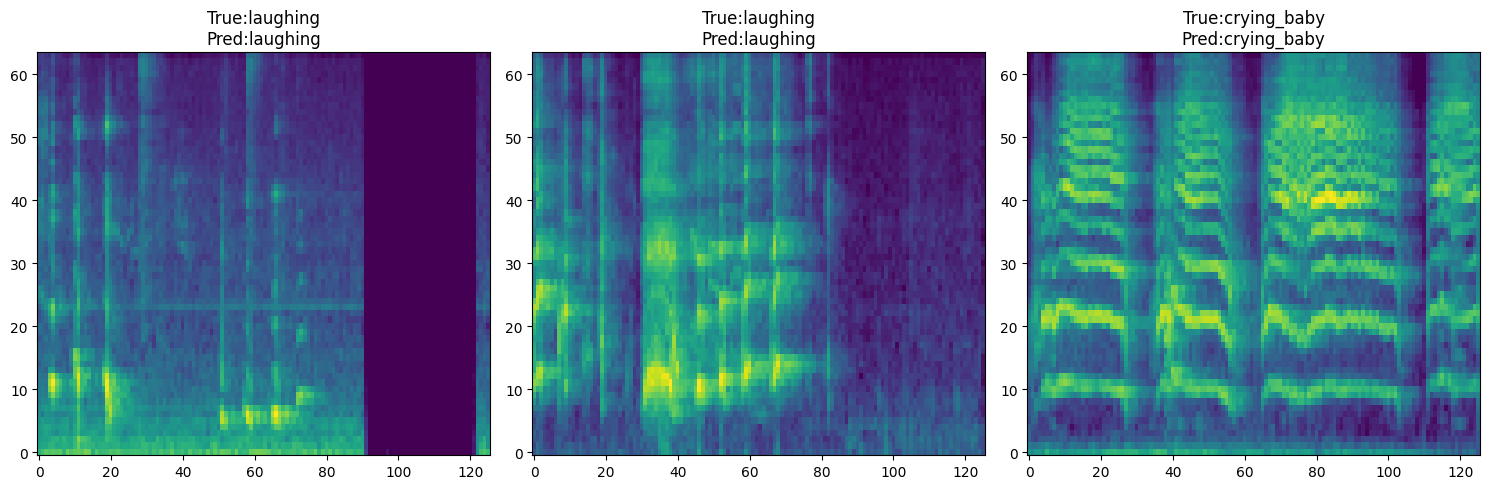

In [77]:
plt.figure(figsize=(15,5))

for i,(img,true,pred) in enumerate(correct):

    plt.subplot(1,3,i+1)

    plt.imshow(
        img.squeeze(),
        aspect="auto",
        origin="lower"
    )

    plt.title(
        f"True:{categories[int(true)]}\nPred:{categories[int(pred)]}"
    )

plt.tight_layout()

plt.show()

# Final Comparison

Compare the performance of the CNN trained **without SpecAugment** and
**with SpecAugment**.

In [78]:
comparison = pd.DataFrame({

    "Metric":[
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1 Score"
    ],

    "Without SpecAugment":[
        test_accuracy,
        macro_precision,
        macro_recall,
        macro_f1
    ],

    "With SpecAugment":[
        accuracy_aug,
        precision_aug,
        recall_aug,
        f1_aug
    ]

})

comparison

,Metric,Without SpecAugment,With SpecAugment
0,Test Accuracy,0.480000,0.200000
1,Macro Precision,0.526501,0.158308
2,Macro Recall,0.480000,0.200000
3,Macro F1 Score,0.463213,0.142253


# Discussion

## Generalization

SpecAugment generally improves generalization because the model learns
to recognize sounds even when parts of the spectrogram are missing.

## Overfitting

Training accuracy may become slightly lower, while validation and test
accuracy often improve. This indicates reduced overfitting.

## Class-wise Performance

Some classes that were previously confused may achieve higher precision
and recall after augmentation.

## Confusion Matrix

The confusion matrix should show fewer misclassifications for several
classes, although a few classes may still remain difficult due to
similar acoustic patterns.

## Conclusion

SpecAugment is an effective regularization technique for audio
classification. By masking random frequency and time regions during
training, it encourages the CNN to learn more robust and
generalizable features.